In [1]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [4]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries(in).csv")


In [5]:
# Check data coverage
print(f"Total matches in CSV: {len(matches)}")


Total matches in CSV: 1095


In [6]:
# Convert date
matches['date'] = pd.to_datetime(matches['date'])

# Remove matches with no result
matches = matches[matches['winner'].notna()]

# Standardize team names (important for consistency)
matches['team1'] = matches['team1'].str.strip()
matches['team2'] = matches['team2'].str.strip()
matches['winner'] = matches['winner'].str.strip()
matches['toss_winner'] = matches['toss_winner'].str.strip()

In [7]:
# Check matches after filtering
print(f"Matches with winners: {len(matches)}")
print(f"Matches excluded (no result): {len(pd.read_csv('matches.csv')) - len(matches)}")


Matches with winners: 1090
Matches excluded (no result): 5


In [8]:
# Extract season year from date
matches['season_year'] = matches['date'].dt.year

In [9]:
matches['toss_win_match_win'] = (matches['toss_winner'] == matches['winner']).astype(int)
toss_win_rate = matches['toss_win_match_win'].value_counts(normalize=True).sort_index()
print(toss_win_rate.tolist())

[0.4917431192660551, 0.5082568807339449]


In [10]:
matches['bat_first'] = matches['toss_decision'].apply(lambda x: 1 if x == 'bat' else 0)

# Did batting first team win?
matches['bat_first_win'] = np.where(
    ((matches['bat_first'] == 1) & (matches['team1'] == matches['winner'])) |
    ((matches['bat_first'] == 0) & (matches['team2'] == matches['winner'])),
    1, 0
)

In [11]:
top_venues = matches['venue'].value_counts().head(10).index

matches['venue_grouped'] = matches['venue'].apply(
    lambda x: x if x in top_venues else 'Other'
)

In [12]:
print(top_venues.tolist())

['Eden Gardens', 'Wankhede Stadium', 'M Chinnaswamy Stadium', 'Feroz Shah Kotla', 'Rajiv Gandhi International Stadium, Uppal', 'MA Chidambaram Stadium, Chepauk', 'Sawai Mansingh Stadium', 'Dubai International Cricket Stadium', 'Wankhede Stadium, Mumbai', 'Punjab Cricket Association Stadium, Mohali']


In [13]:
matches = matches.sort_values('date')

team_form = {}

form_list = []

for idx, row in matches.iterrows():
    team1 = row['team1']
    team2 = row['team2']

    def get_form(team):
        if team not in team_form:
            return 0.5  # neutral
        return np.mean(team_form[team][-5:]) if len(team_form[team]) >= 1 else 0.5

    form1 = get_form(team1)
    form2 = get_form(team2)

    form_list.append((form1, form2))

    # Update history
    winner = row['winner']
    for team in [team1, team2]:
        if team not in team_form:
            team_form[team] = []

    team_form[winner].append(1)
    loser = team1 if winner == team2 else team2
    team_form[loser].append(0)

matches['team1_form'] = [f[0] for f in form_list]
matches['team2_form'] = [f[1] for f in form_list]

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
matches['team1'] = le.fit_transform(matches['team1'])
matches['team2'] = le.transform(matches['team2'])

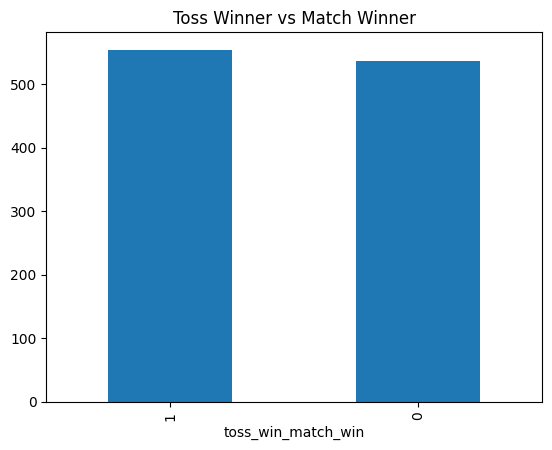

In [15]:
matches['toss_win_match_win'].value_counts().plot(kind='bar')
plt.title("Toss Winner vs Match Winner")
plt.show()

In [16]:
bat_win_rate = matches['bat_first_win'].mean()
print("Bat First Win %:", bat_win_rate * 100)

Bat First Win %: 52.56880733944954


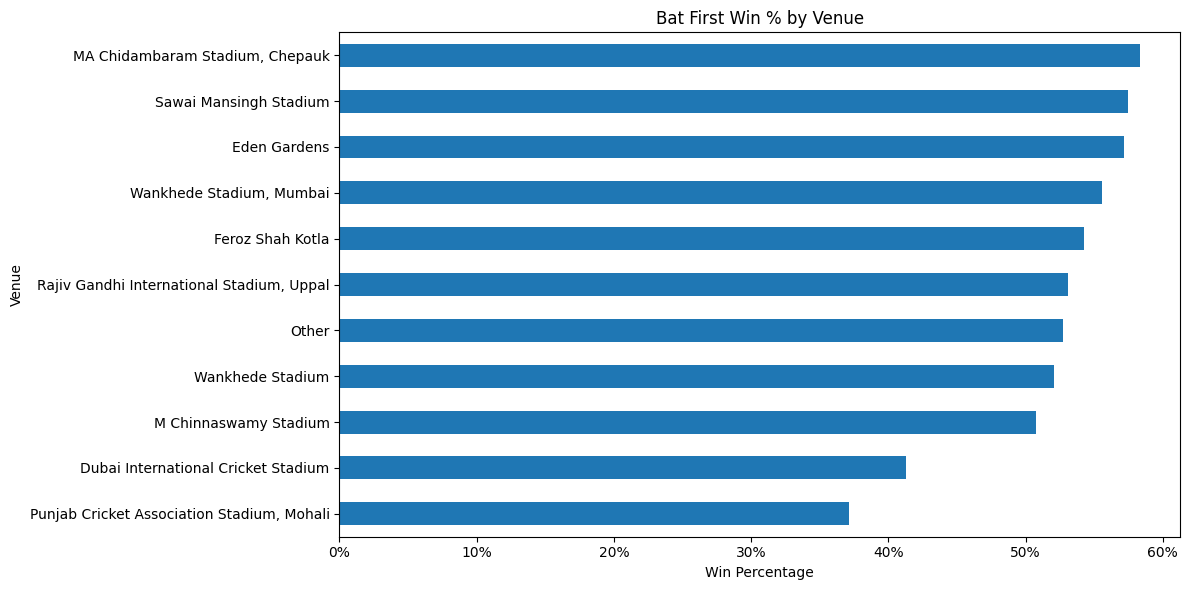

In [17]:
venue_win = matches.groupby('venue_grouped')['bat_first_win'].mean()
venue_win = venue_win.sort_values()

fig, ax = plt.subplots(figsize=(12,6))

venue_win.plot(kind='barh', ax=ax)

# Format as percentage
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.set_title("Bat First Win % by Venue")
ax.set_xlabel("Win Percentage")
ax.set_ylabel("Venue")

plt.tight_layout()
plt.show()

In [18]:
matches['team1_win'] = (matches['winner'] == matches['team1']).astype(int)

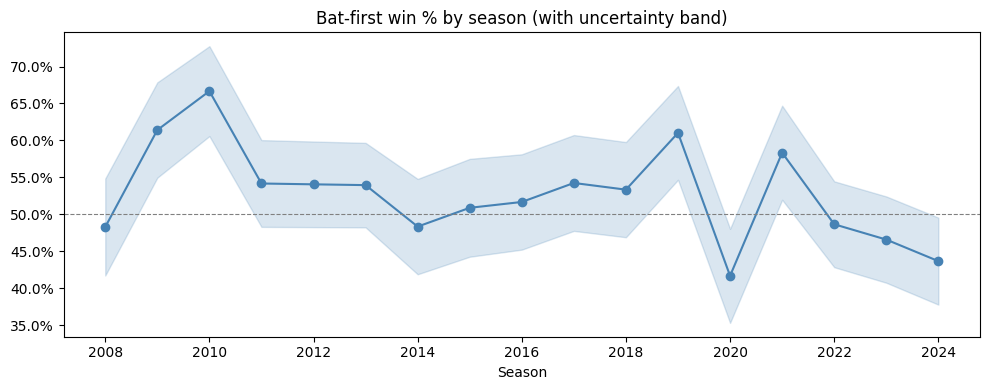

In [19]:
# ── 5. Season trend: bat-first win % with confidence band ─────────────────────
season_stats = matches.groupby('season_year').agg(
    win_rate=('bat_first_win','mean'),
    n=('bat_first_win','count')
).reset_index()
season_stats['se'] = np.sqrt(
    season_stats['win_rate'] * (1 - season_stats['win_rate']) / season_stats['n'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(season_stats['season_year'], season_stats['win_rate']*100,
        marker='o', color='steelblue')
ax.fill_between(season_stats['season_year'],
    (season_stats['win_rate'] - season_stats['se'])*100,
    (season_stats['win_rate'] + season_stats['se'])*100,
    alpha=0.2, color='steelblue')
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Bat-first win % by season (with uncertainty band)")
ax.set_xlabel("Season"); plt.tight_layout(); plt.show()

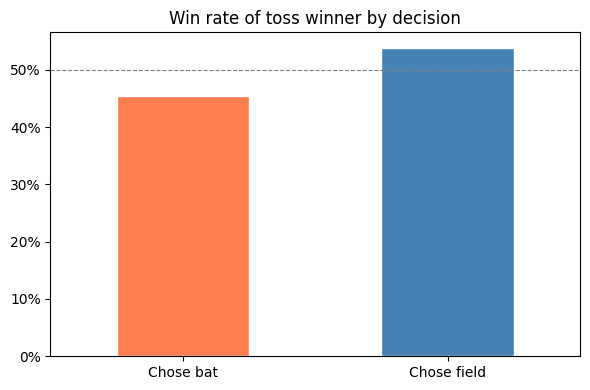

In [20]:
# ── 4. Toss decision × outcome — the key conditional chart ────────────────────
toss_cond = matches.groupby(['toss_decision','toss_win_match_win']).size().unstack(fill_value=0)
toss_cond = toss_cond.div(toss_cond.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(6, 4))
toss_cond[1].plot(kind='bar', ax=ax, color=['coral','steelblue'], edgecolor='white', width=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
ax.set_title("Win rate of toss winner by decision")
ax.set_xticklabels(['Chose bat','Chose field'], rotation=0)
ax.set_xlabel(""); plt.tight_layout(); plt.show()

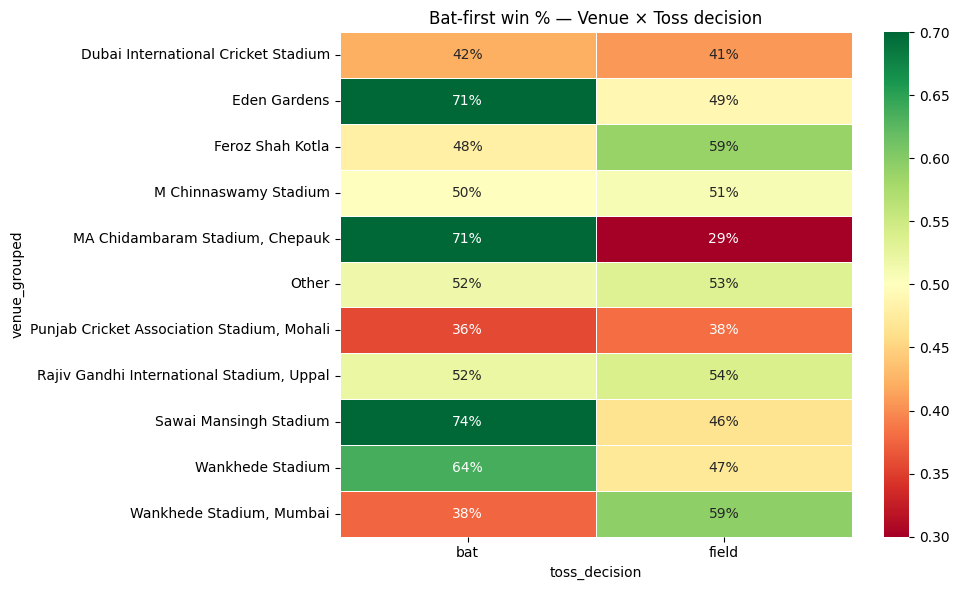

In [21]:
# ── 2. Bat-first win % by venue × toss decision (heatmap) ────────────────────
heatmap_data = matches.groupby(['venue_grouped','toss_decision'])['bat_first_win'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0%", cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0.3, vmax=0.7)
ax.set_title("Bat-first win % — Venue × Toss decision")
plt.tight_layout(); plt.show()